# Model Comparison Pipeline

This notebook performs advanced machine learning model comparison for Parkinson’s disease prediction using selected voice features.

---

## Key Objectives

- Compare multiple classification algorithms
- Evaluate model performance and stability
- Identify the best-performing model
- Analyze prediction behavior and feature contribution


## Workflow

###  Data Loading
The selected feature dataset is loaded and prepared for modeling.

In [38]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [39]:
df = pd.read_csv('../data/selected_features.csv')
df.head()

,spread1,PPE,spread2,MDVP:Fo(Hz),status
0,-4.813031,0.284654,0.266482,119.992,1
1,-4.075192,0.368674,0.335590,122.400,1
2,-4.443179,0.332634,0.311173,116.682,1
3,-4.117501,0.368975,0.334147,116.676,1
4,-3.747787,0.410335,0.234513,116.014,1


In [40]:
df.shape

(195, 5)

## Data Splitting

The dataset is divided into training and testing sets to evaluate model generalization performance.

- Training Set: `(156, 4)`
- Testing Set: `(39, 4)`

Selected Features:

- `spread1`
- `PPE`
- `spread2`
- `MDVP:Fo(Hz)`

The training data is used to train machine learning models, while the testing data is used to evaluate prediction performance on unseen samples.

In [41]:
X= df.drop('status', axis=1)
y = df['status']

print("Selected Features: ")
print(X.columns.tolist())

Selected Features: 
['spread1', 'PPE', 'spread2', 'MDVP:Fo(Hz)']


In [42]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")

Training set size: (156, 4)
Testing set size: (39, 4)


###  Feature Scaling
Standardization is applied to normalize feature values before training.

In [43]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Model Training
Multiple machine learning algorithms are trained:

- Logistic Regression
- SVM
- KNN
- Decision Tree
- Random Forest
- Gradient Boosting
- AdaBoost

In [44]:
models = {
    'Logistic Regression': LogisticRegression(),
    'SVM': SVC(),
    'KNN': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'AdaBoost': AdaBoostClassifier(random_state=42)
}

## Best Model Selection

Multiple machine learning models were evaluated using Test Accuracy and Cross Validation Accuracy.

| Model | Test Accuracy | CV Score |
|---|---|---|
| Logistic Regression | 0.923 | 0.820 |
| SVM | 0.872 | 0.859 |
| KNN | 0.872 | 0.852 |
| Decision Tree | 0.846 | 0.840 |
| Random Forest | 0.897 | 0.885 |
| Gradient Boosting | 0.872 | 0.891 |
| AdaBoost | 0.872 | 0.891 |

### Observation

- Logistic Regression achieved the highest test accuracy (`92.3%`).
- Ensemble models such as Gradient Boosting and AdaBoost showed strong cross-validation performance.
- Decision Tree produced the lowest accuracy among all models.

### Final Selection

Logistic Regression was selected as the best baseline model due to its superior prediction accuracy and stable classification performance.

In [45]:
results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    cv_score = cross_val_score(model, X_train_scaled, y_train, cv=5).mean()
    results[name] = {'Test Accuracy': acc, 'CV Score': cv_score}

    print(f'{name}')
    print('_'*50)
    print('Test Accuracy: ', acc)
    print('Cross Validation accuracy: ', cv_score)
    print()

Logistic Regression
__________________________________________________
Test Accuracy:  0.9230769230769231
Cross Validation accuracy:  0.8203629032258066

SVM
__________________________________________________
Test Accuracy:  0.8717948717948718
Cross Validation accuracy:  0.8586693548387098

KNN
__________________________________________________
Test Accuracy:  0.8717948717948718
Cross Validation accuracy:  0.8522177419354839

Decision Tree
__________________________________________________
Test Accuracy:  0.8461538461538461
Cross Validation accuracy:  0.8395161290322581

Random Forest
__________________________________________________
Test Accuracy:  0.8974358974358975
Cross Validation accuracy:  0.8846774193548388

Gradient Boosting
__________________________________________________
Test Accuracy:  0.8717948717948718
Cross Validation accuracy:  0.890725806451613

AdaBoost
__________________________________________________
Test Accuracy:  0.8717948717948718
Cross Validation accuracy:  

In [46]:
results_df = pd.DataFrame(results).T
print("Model Comparison Results:")
results_df

Model Comparison Results:


,Test Accuracy,CV Score
Logistic Regression,0.923077,0.820363
SVM,0.871795,0.858669
KNN,0.871795,0.852218
Decision Tree,0.846154,0.839516
Random Forest,0.897436,0.884677
Gradient Boosting,0.871795,0.890726
AdaBoost,0.871795,0.891129


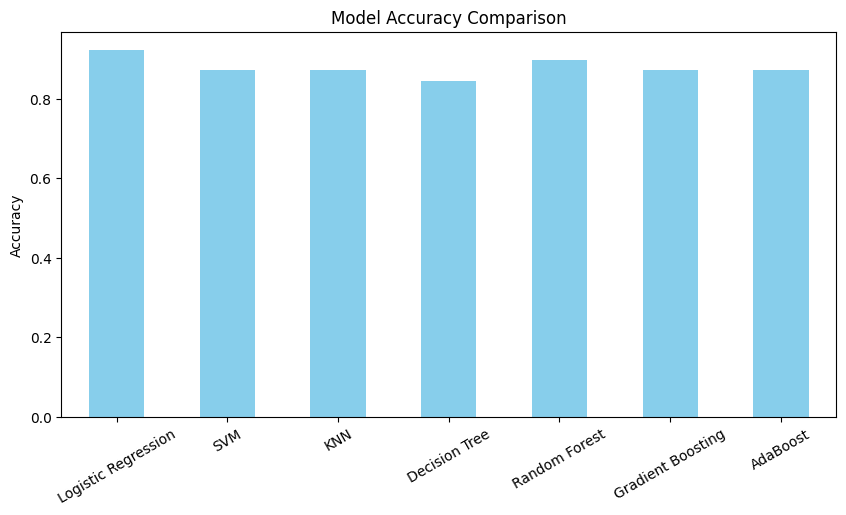

In [47]:
plt.figure(figsize=(10, 5))

results_df['Test Accuracy'].plot(kind='bar', color='skyblue')

plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.xticks(rotation=30)
plt.show()

In [48]:
bast_model_name = results_df['Test Accuracy'].idxmax()

print('Best Model:', bast_model_name)

Best Model: Logistic Regression


In [49]:
best_model = models[bast_model_name]
best_model.fit(X_train_scaled, y_train)
y_pred = best_model.predict(X_test_scaled)

print('\n Classification Report: ')
print(classification_report(y_test, y_pred))


 Classification Report: 
              precision    recall  f1-score   support

           0       1.00      0.57      0.73         7
           1       0.91      1.00      0.96        32

    accuracy                           0.92        39
   macro avg       0.96      0.79      0.84        39
weighted avg       0.93      0.92      0.91        39



## Confusion Matrix Analysis

| Actual / Predicted | Class 0 | Class 1 |
|---|---|---|
| Class 0 | 4 | 3 |
| Class 1 | 0 | 32 |

### Interpretation

- **True Negative (TN) = 4**  
  Correctly predicted healthy cases.

- **False Positive (FP) = 3**  
  Healthy samples incorrectly predicted as Parkinson’s.

- **False Negative (FN) = 0**  
  No Parkinson’s cases were missed by the model.

- **True Positive (TP) = 32**  
  Correctly predicted Parkinson’s cases.

### Observation

The model achieved strong classification performance with zero false negatives, indicating effective detection of Parkinson’s disease cases.

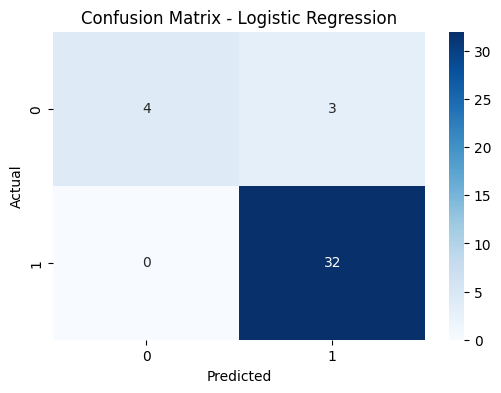

In [50]:
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix - {bast_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Feature Coefficient Analysis

| Feature | Coefficient | Interpretation |
|---|---|---|
| PPE | 1.275 | Strong positive contribution toward Parkinson’s prediction |
| spread1 | 0.966 | Higher frequency variation increases disease probability |
| spread2 | 0.512 | Positively influences Parkinson’s classification |
| MDVP:Fo(Hz) | -0.170 | Higher vocal frequency reduces disease probability |

### Observation

- `PPE` is the most influential feature in the Logistic Regression model.
- Positive coefficients indicate increased probability of Parkinson’s disease.
- Negative coefficients indicate reduced probability of disease prediction.
- The model behavior aligns with medical voice pattern characteristics of Parkinson’s patients.

       Feature  Coefficient
1          PPE     1.275685
0      spread1     0.966226
2      spread2     0.511913
3  MDVP:Fo(Hz)    -0.169998


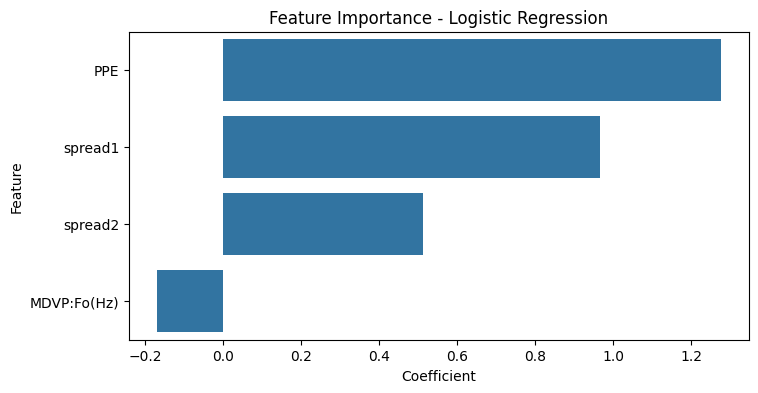

In [52]:
importance = pd.DataFrame({

    "Feature": X.columns,

    "Coefficient": best_model.coef_[0]

})

importance = importance.sort_values(
    by="Coefficient",
    ascending=False
)

print(importance)

plt.figure(figsize=(8,4))

sns.barplot(
    x="Coefficient",
    y="Feature",
    data=importance
)

plt.title(
    "Feature Importance - Logistic Regression"
)

plt.show()

## Saving Model Comparison Results

The final model comparison results are exported as a CSV file for documentation and future analysis.



In [55]:
results_df.to_csv(

    "../results/model_comparison_results.csv",

    index=True
)

print(
    "\nModel comparison results saved successfully."
)


Model comparison results saved successfully.
